In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math, warnings
warnings.filterwarnings("ignore")

from google.colab import files
import io

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     KFold, StratifiedKFold)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, RandomForestClassifier,
                               GradientBoostingClassifier)
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.svm import SVR, NuSVR, SVC
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, classification_report,
                              confusion_matrix, f1_score)
from sklearn.inspection import permutation_importance
from joblib import dump, load

print("All imports done!")


All imports done!


In [ ]:

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_raw   = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Loaded: {filename}  |  Shape: {df_raw.shape}")
df_raw.head()


Saving Smart_Irrigation_FAO56_8000.csv to Smart_Irrigation_FAO56_8000.csv
Loaded: Smart_Irrigation_FAO56_8000.csv  |  Shape: (8000, 32)


,doy,month,hour,growth_stage,temperature_mean_C,temperature_max_C,temperature_min_C,humidity_pct,wind_speed_2m_ms,rainfall_mm,...,VPD_kPa,ETo_mm_day,Kc,ETc_mm_day,Ks_stress_coeff,Pe_eff_rain_day_mm,CWR_mm_per_day,soil_fertility_score,fertility_class,irrigation_needed
0,103,4,7,2,34.08,38.97,29.75,46.60,1.999,43.82,...,2.9807,5.3191,0.85,4.5212,0.8774,1.1535,2.8226,72.60,Medium,1
1,349,12,14,2,22.75,27.04,19.06,37.01,1.658,19.37,...,1.8202,4.0162,0.85,3.4138,0.9493,0.5856,2.6508,60.05,Medium,1
2,271,10,14,3,25.45,30.15,22.04,57.39,0.915,15.58,...,1.4764,4.3338,1.15,4.9838,1.0000,0.4805,4.4890,79.00,High,1
3,107,4,10,2,36.22,41.70,31.08,58.76,2.827,8.70,...,2.5953,6.5581,0.85,5.5744,0.9458,0.2779,4.9776,73.71,Medium,1
4,72,3,16,2,25.22,29.20,20.33,42.62,5.370,33.18,...,1.8469,6.6991,0.85,5.6942,0.7570,0.9299,3.3777,39.12,Low,1


In [ ]:
print(df_raw.dtypes)
print(f"\nMissing values:\n{df_raw.isnull().sum()[df_raw.isnull().sum()>0]}")
display(df_raw.describe().T.round(3))


doy                       int64
month                     int64
hour                      int64
growth_stage              int64
temperature_mean_C      float64
temperature_max_C       float64
temperature_min_C       float64
humidity_pct            float64
wind_speed_2m_ms        float64
rainfall_mm             float64
sunshine_hours          float64
soil_moisture_pct       float64
soil_ph                 float64
nitrogen_mgkg           float64
phosphorus_mgkg         float64
potassium_mgkg          float64
crop_health_score       float64
Ra_MJ_m2_day            float64
Rs_MJ_m2_day            float64
Rn_MJ_m2_day            float64
es_kPa                  float64
ea_kPa                  float64
VPD_kPa                 float64
ETo_mm_day              float64
Kc                      float64
ETc_mm_day              float64
Ks_stress_coeff         float64
Pe_eff_rain_day_mm      float64
CWR_mm_per_day          float64
soil_fertility_score    float64
fertility_class          object
irrigati

,count,mean,std,min,25%,50%,75%,max
doy,8000.0,182.075,105.139,1.000,93.000,181.000,273.000,365.000
month,8000.0,6.548,3.486,1.000,4.000,7.000,10.000,12.000
hour,8000.0,12.045,3.758,6.000,9.000,12.000,15.000,18.000
growth_stage,8000.0,2.499,1.111,1.000,2.000,2.000,3.000,4.000
temperature_mean_C,8000.0,26.621,4.588,15.070,23.420,25.950,29.212,42.650
temperature_max_C,8000.0,31.131,4.672,18.980,27.870,30.550,33.770,48.000
temperature_min_C,8000.0,22.131,4.655,10.080,18.870,21.550,24.800,38.000
humidity_pct,8000.0,61.676,17.141,20.000,48.630,58.310,75.342,98.000
wind_speed_2m_ms,8000.0,2.641,1.377,0.374,1.591,2.486,3.486,8.975
rainfall_mm,8000.0,40.162,61.627,0.000,6.195,18.510,42.930,400.000


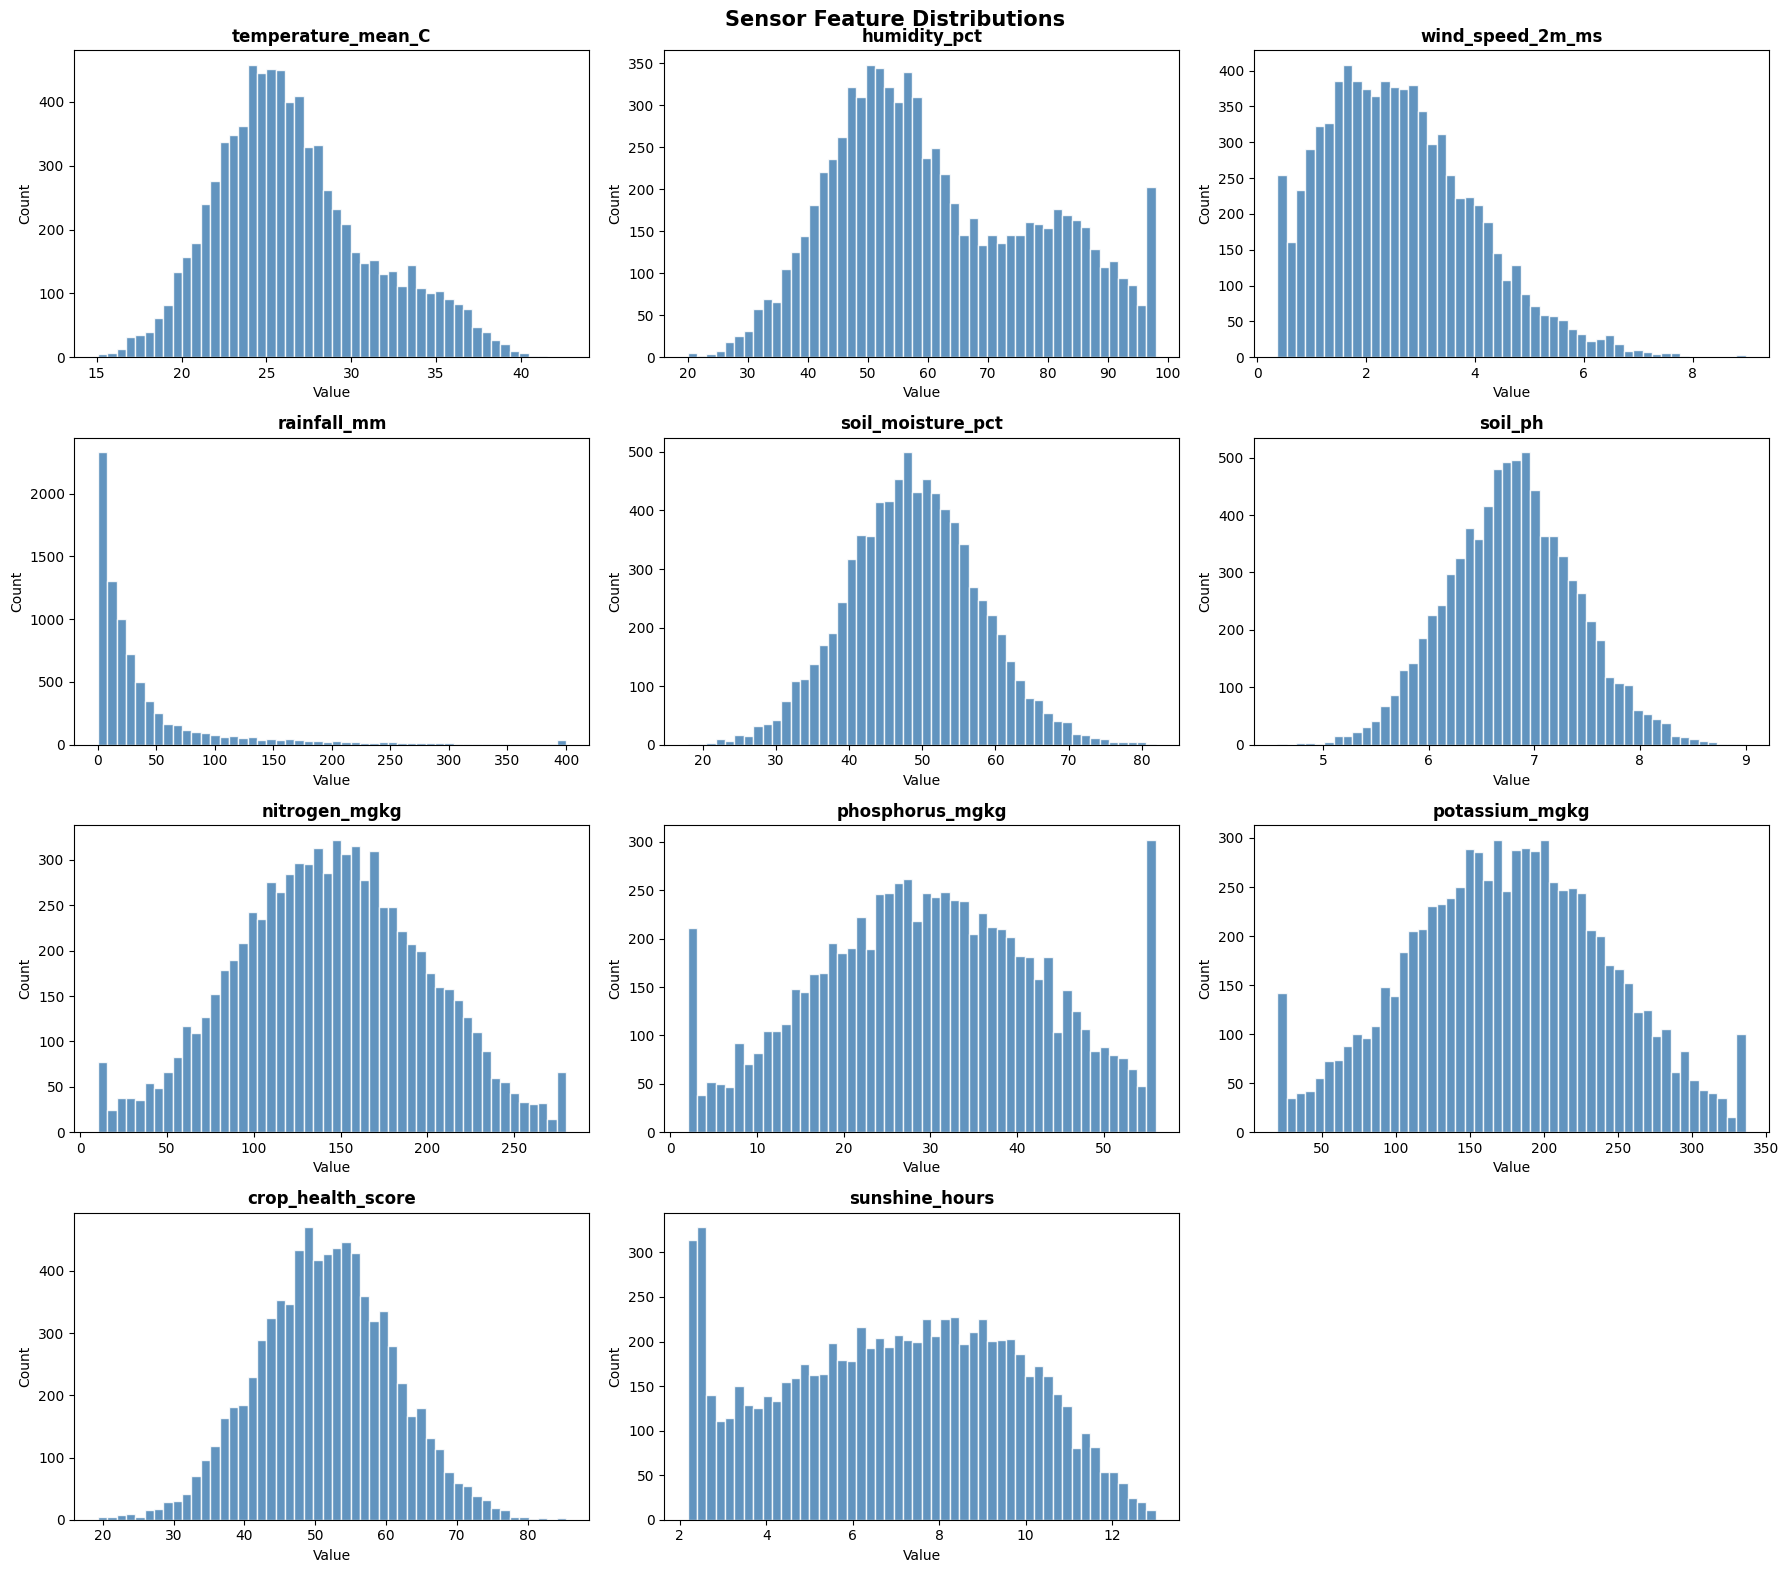

In [ ]:
sensor_cols = ['temperature_mean_C','humidity_pct','wind_speed_2m_ms',
               'rainfall_mm','soil_moisture_pct','soil_ph',
               'nitrogen_mgkg','phosphorus_mgkg','potassium_mgkg',
               'crop_health_score','sunshine_hours']

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()
for i, col in enumerate(sensor_cols):
    axes[i].hist(df_raw[col], bins=50, color='steelblue',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel("Value"); axes[i].set_ylabel("Count")
axes[-1].axis('off')
plt.suptitle("Sensor Feature Distributions", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


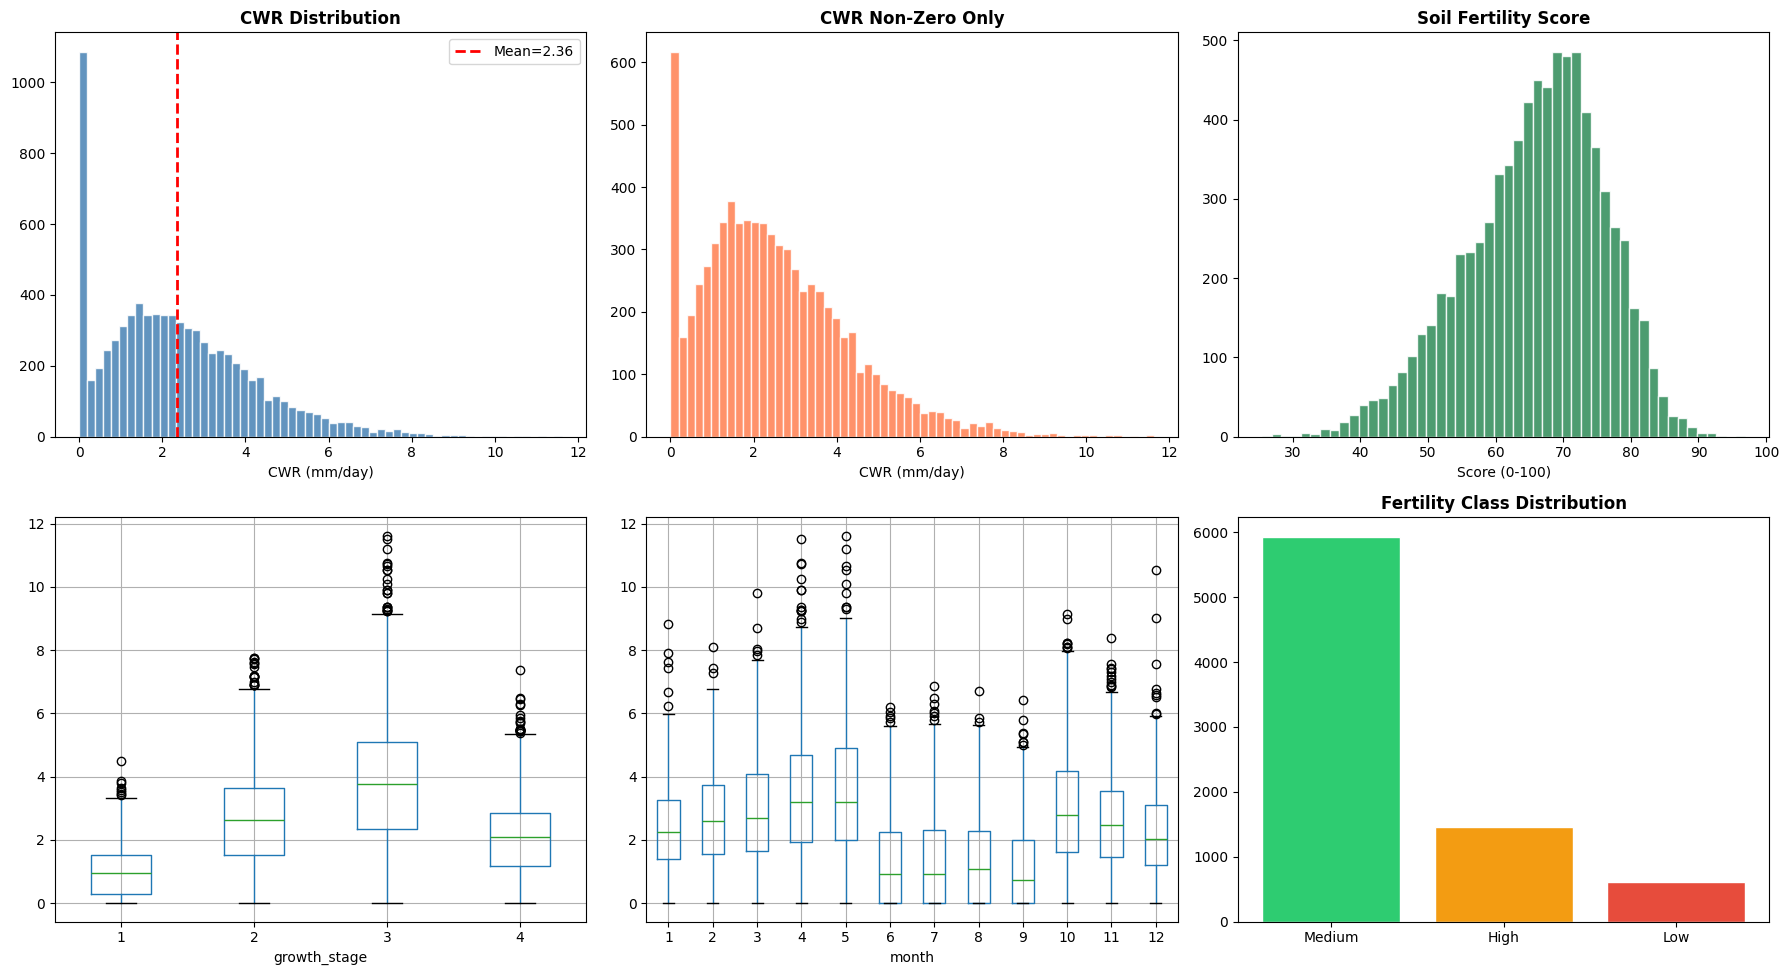


Zero CWR rows: 470 (5.9%) - No irrigation needed (physically correct)


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].hist(df_raw['CWR_mm_per_day'], bins=60, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_raw['CWR_mm_per_day'].mean(), color='red',
                  linestyle='--', linewidth=2,
                  label=f"Mean={df_raw['CWR_mm_per_day'].mean():.2f}")
axes[0,0].set_title('CWR Distribution', fontweight='bold')
axes[0,0].set_xlabel('CWR (mm/day)'); axes[0,0].legend()

nz = df_raw[df_raw['CWR_mm_per_day']>0]['CWR_mm_per_day']
axes[0,1].hist(nz, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[0,1].set_title('CWR Non-Zero Only', fontweight='bold')
axes[0,1].set_xlabel('CWR (mm/day)')

axes[0,2].hist(df_raw['soil_fertility_score'], bins=50,
               color='seagreen', edgecolor='white', alpha=0.85)
axes[0,2].set_title('Soil Fertility Score', fontweight='bold')
axes[0,2].set_xlabel('Score (0-100)')

df_raw.boxplot(column='CWR_mm_per_day', by='growth_stage', ax=axes[1,0])
axes[1,0].set_title('CWR by Growth Stage', fontweight='bold')
plt.sca(axes[1,0]); plt.title('')

df_raw.boxplot(column='CWR_mm_per_day', by='month', ax=axes[1,1])
axes[1,1].set_title('CWR by Month', fontweight='bold')
plt.sca(axes[1,1]); plt.title('')

fc_counts = df_raw['fertility_class'].value_counts()
axes[1,2].bar(fc_counts.index, fc_counts.values,
              color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='white')
axes[1,2].set_title('Fertility Class Distribution', fontweight='bold')

plt.suptitle(''); plt.tight_layout(); plt.show()
print(f"\nZero CWR rows: {(df_raw['CWR_mm_per_day']==0).sum()} "
      f"({(df_raw['CWR_mm_per_day']==0).mean()*100:.1f}%) "
      f"- No irrigation needed (physically correct)")

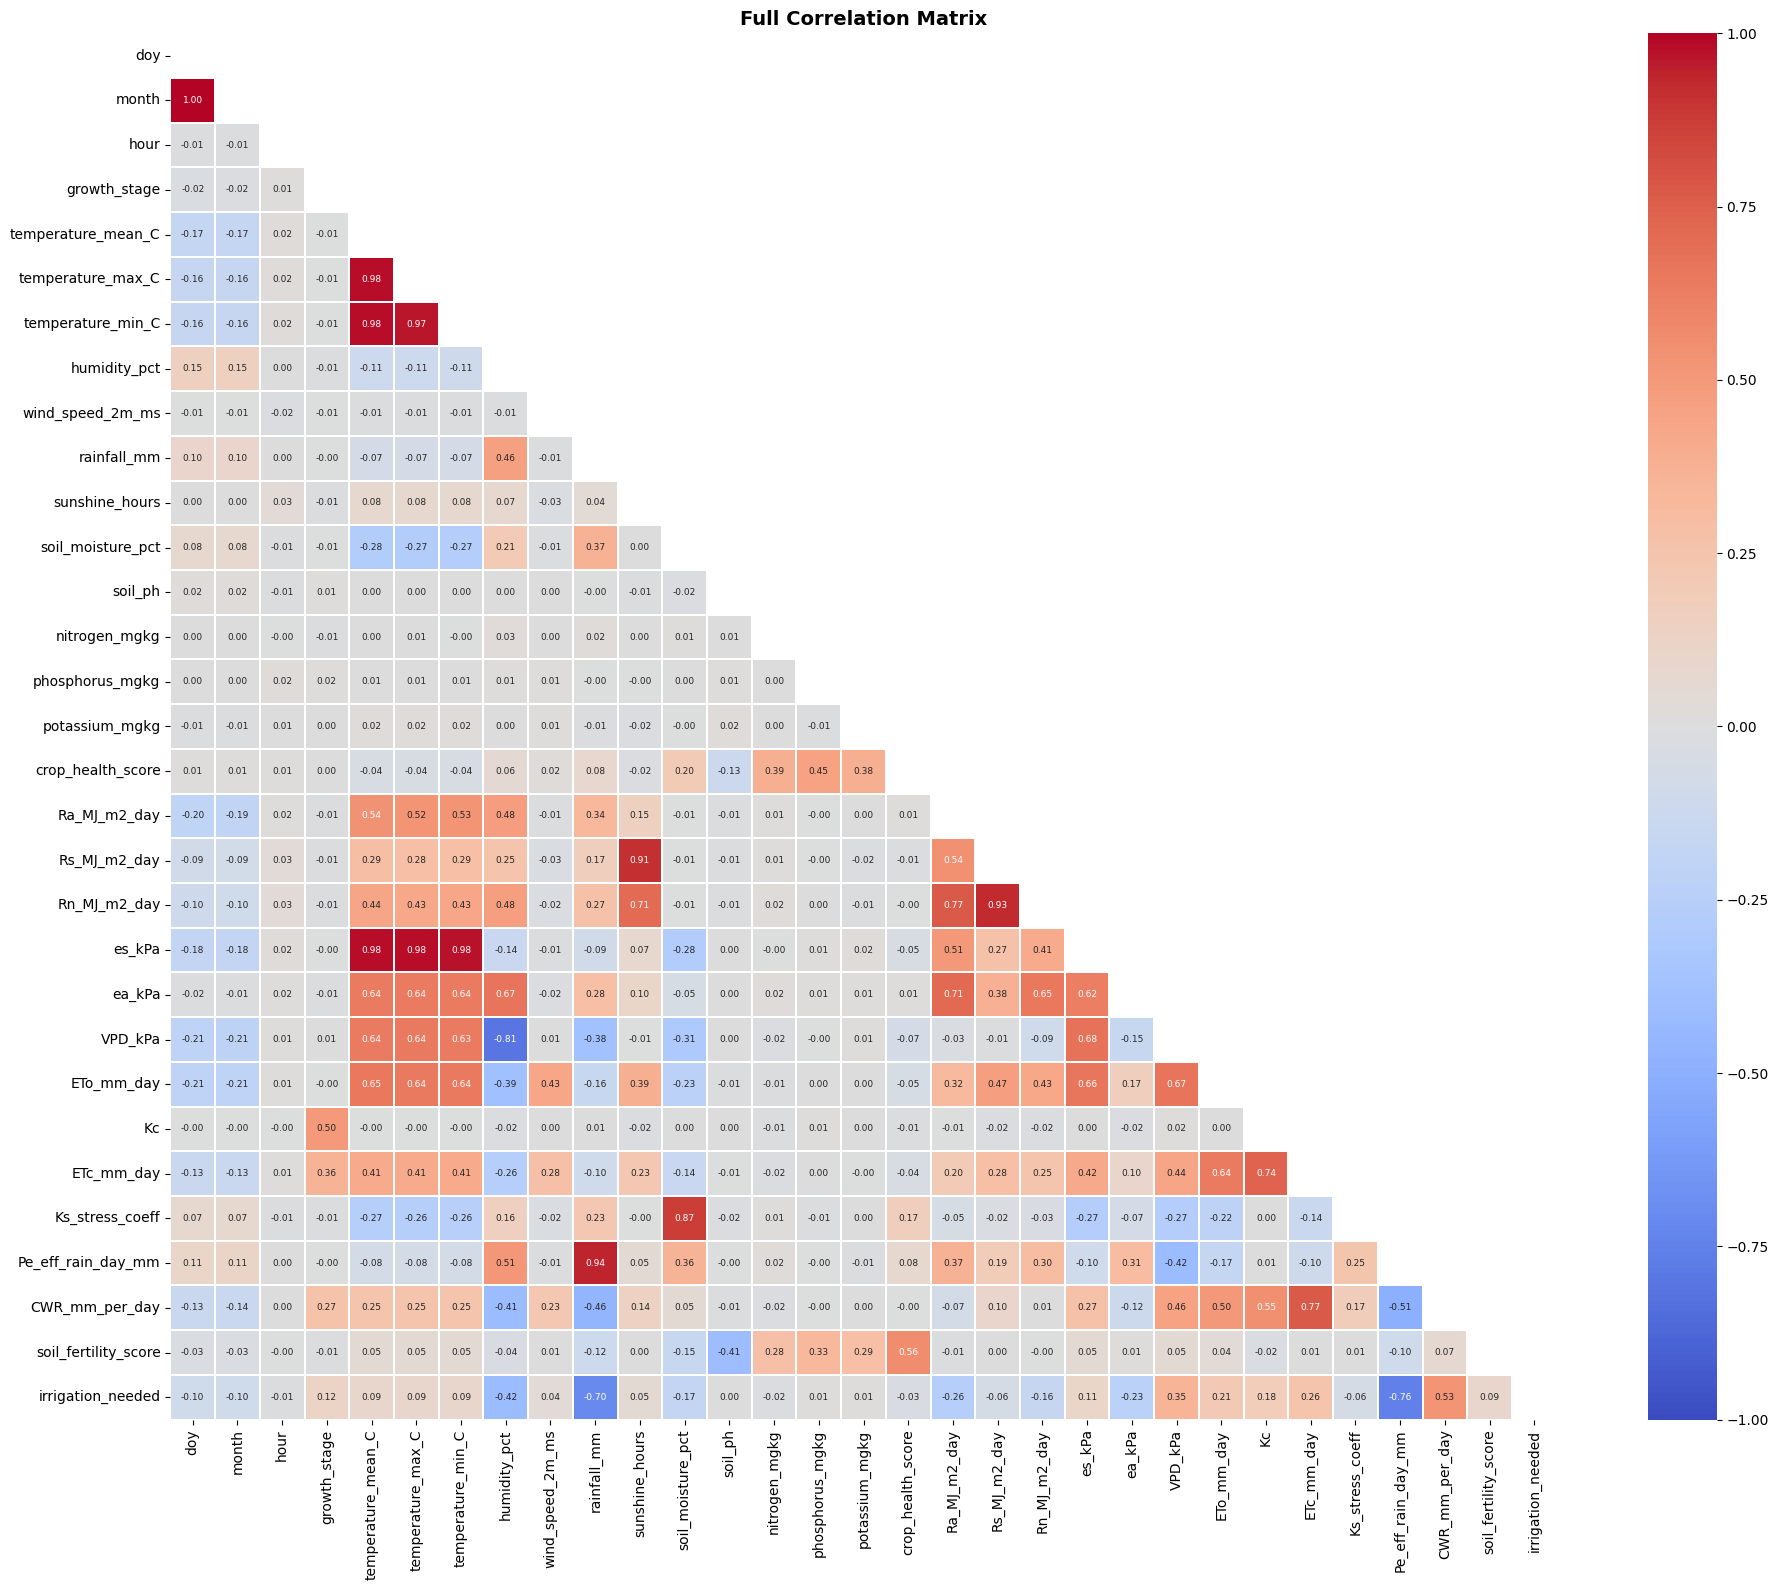


Top correlations with CWR:
CWR_mm_per_day        1.000000
ETc_mm_day            0.767604
Kc                    0.552923
irrigation_needed     0.528777
Pe_eff_rain_day_mm    0.507391
ETo_mm_day            0.500133
rainfall_mm           0.461149
VPD_kPa               0.455192
humidity_pct          0.414561
es_kPa                0.268989
growth_stage          0.265395
temperature_max_C     0.254343
temperature_min_C     0.253890
temperature_mean_C    0.252645
wind_speed_2m_ms      0.227335
Name: CWR_mm_per_day, dtype: float64


In [ ]:
numeric_df = df_raw.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.3, square=True, vmin=-1, vmax=1,
            annot_kws={'size': 6.5})
plt.title('Full Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nTop correlations with CWR:")
print(corr['CWR_mm_per_day'].abs().sort_values(ascending=False).head(15))


In [ ]:
df = df_raw.copy()


df['temp_range_C']       = df['temperature_max_C'] - df['temperature_min_C']

df['heat_stress']        = np.where(df['temperature_max_C'] > 35,
                           (df['temperature_max_C'] - 35) * 0.1, 0)

df['VPD_stress']         = np.clip(df['VPD_kPa'] - 1.0, 0, None)

df['aridity_index']      = df['rainfall_mm'] / (df['ETo_mm_day'] + 1e-6)

df['water_deficit_mm']   = np.maximum(df['ETo_mm_day'] -
                           df['Pe_eff_rain_day_mm'], 0)

df['NPK_composite']      = ((df['nitrogen_mgkg']/280) +
                            (df['phosphorus_mgkg']/56) +
                            (df['potassium_mgkg']/336)) / 3 * 100

df['pH_deviation']       = np.abs(df['soil_ph'] - 6.5)

df['soil_atm_ratio']     = df['soil_moisture_pct'] / (df['ETo_mm_day'] + 1e-6)

df['rad_crop_load']      = df['Rs_MJ_m2_day'] * df['Kc']


df['WUE_proxy']          = df['crop_health_score'] / (df['ETc_mm_day'] + 1e-6)

df['doy_sin']            = np.sin(2*np.pi*df['doy']/365)
df['doy_cos']            = np.cos(2*np.pi*df['doy']/365)
df['month_sin']          = np.sin(2*np.pi*df['month']/12)
df['month_cos']          = np.cos(2*np.pi*df['month']/12)
df['hour_sin']           = np.sin(2*np.pi*df['hour']/24)
df['hour_cos']           = np.cos(2*np.pi*df['hour']/24)

print(f"Feature engineering complete. Shape: {df.shape}")


Feature engineering complete. Shape: (8000, 48)


In [ ]:
FEATURES = [
    # RTC DS3231 - cyclic encoded
    'doy_sin','doy_cos','month_sin','month_cos','hour_sin','hour_cos',
    'growth_stage',
    # DHT11
    'temperature_mean_C','temperature_max_C','temperature_min_C',
    'humidity_pct','temp_range_C','heat_stress',
    # Weather
    'wind_speed_2m_ms','rainfall_mm','sunshine_hours',
    # ADS1115
    'soil_moisture_pct','soil_ph',
    # NPK MAX485
    'nitrogen_mgkg','phosphorus_mgkg','potassium_mgkg','NPK_composite',
    # Phone Camera
    'crop_health_score',
    # FAO-56 computed (Pi computes these from sensors + date)
    'Ra_MJ_m2_day','Rs_MJ_m2_day','Rn_MJ_m2_day',
    'es_kPa','ea_kPa','VPD_kPa','VPD_stress',
    'ETo_mm_day','Kc','ETc_mm_day','Ks_stress_coeff','Pe_eff_rain_day_mm',
    # Engineered
    'aridity_index','water_deficit_mm','pH_deviation',
    'soil_atm_ratio','rad_crop_load','WUE_proxy',
]

X = df[FEATURES]
print(f"Feature matrix: {X.shape}  |  Total features: {len(FEATURES)}")



Feature matrix: (8000, 41)  |  Total features: 41


In [ ]:
def evaluate_regression(name, model, X_tr, y_tr, X_te, y_te, n_features, cv=5):
    """
    MSE, RMSE, MAE, R2, Adjusted R2, MAPE, 5-Fold CV R2
    Adjusted R2 = 1 - (1-R2)*(n-1)/(n-p-1)
    where n=samples, p=features (penalises unnecessary features)
    """
    y_pred  = np.clip(model.predict(X_te), 0, None)  # CWR >= 0 physically
    n, p    = len(y_te), n_features
    mse     = mean_squared_error(y_te, y_pred)
    rmse    = np.sqrt(mse)
    mae     = mean_absolute_error(y_te, y_pred)
    r2      = r2_score(y_te, y_pred)
    adj_r2  = 1 - (1-r2)*(n-1)/(n-p-1)
    mask    = y_te > 0.01
    mape    = (np.mean(np.abs((y_te[mask]-y_pred[mask])/y_te[mask]))*100
               if mask.sum()>0 else np.nan)
    kf      = KFold(n_splits=cv, shuffle=True, random_state=42)
    cv_r2   = cross_val_score(model, X_tr, y_tr, cv=kf,
                               scoring='r2', n_jobs=-1)
    return {
        'Model':      name,
        'MSE':        round(mse,   4),
        'RMSE':       round(rmse,  4),
        'MAE':        round(mae,   4),
        'R2':         round(r2,    4),
        'Adj_R2':     round(adj_r2,4),
        'MAPE_pct':   round(mape,  2) if not np.isnan(mape) else 'N/A',
        'CV_R2_mean': round(cv_r2.mean(),4),
        'CV_R2_std':  round(cv_r2.std(), 4),
    }, y_pred


def evaluate_classification(name, model, X_te, y_te, classes):
    y_pred = model.predict(X_te)
    return {
        'Model':       name,
        'Accuracy':    round(accuracy_score(y_te, y_pred), 4),
        'F1_weighted': round(f1_score(y_te, y_pred, average='weighted'), 4),
    }, y_pred, classification_report(y_te, y_pred, target_names=classes), \
       confusion_matrix(y_te, y_pred)


In [ ]:
y_cwr = df['CWR_mm_per_day']
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X, y_cwr, test_size=0.2, random_state=42)
scaler_cwr  = StandardScaler()
X_tr_cs     = scaler_cwr.fit_transform(X_tr_c)
X_te_cs     = scaler_cwr.transform(X_te_c)

cwr_models = {
    'Random Forest':     RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                         random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                         max_depth=5, subsample=0.8, random_state=42),
    'Extra Trees':       ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet':        ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    'SVR_RBF':           SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'),
    'NuSVR':             NuSVR(kernel='rbf', C=10, nu=0.5, gamma='scale'),
}

cwr_results, cwr_preds = [], {}
print("Training CWR Regression Models...")
for name, model in cwr_models.items():
    model.fit(X_tr_cs, y_tr_c)
    res, yp = evaluate_regression(name, model, X_tr_cs, y_tr_c,
                                  X_te_cs, y_te_c, len(FEATURES))
    cwr_results.append(res); cwr_preds[name] = yp
    print(f"  {name:22s} | R2={res['R2']:.4f} | RMSE={res['RMSE']:.4f}"
          f" | CV={res['CV_R2_mean']:.4f}+-{res['CV_R2_std']:.4f}")

cwr_df = pd.DataFrame(cwr_results).sort_values('Adj_R2', ascending=False).reset_index(drop=True)
display(cwr_df)

best_cwr_name  = cwr_df.iloc[0]['Model']
best_cwr_model = cwr_models[best_cwr_name]
best_cwr_preds = cwr_preds[best_cwr_name]
print(f"\nBest CWR Model: {best_cwr_name}")

Training CWR Regression Models...
  Random Forest          | R2=0.9956 | RMSE=0.1177 | CV=0.9940+-0.0006
  Gradient Boosting      | R2=0.9978 | RMSE=0.0835 | CV=0.9972+-0.0001
  Extra Trees            | R2=0.9980 | RMSE=0.0791 | CV=0.9975+-0.0003
  Ridge                  | R2=0.9579 | RMSE=0.3658 | CV=0.9386+-0.0027
  Lasso                  | R2=0.9516 | RMSE=0.3922 | CV=0.9306+-0.0023
  ElasticNet             | R2=0.9543 | RMSE=0.3809 | CV=0.9340+-0.0022
  SVR_RBF                | R2=0.9945 | RMSE=0.1325 | CV=0.9911+-0.0015
  NuSVR                  | R2=0.9969 | RMSE=0.0996 | CV=0.9939+-0.0012


,Model,MSE,RMSE,MAE,R2,Adj_R2,MAPE_pct,CV_R2_mean,CV_R2_std
0,Extra Trees,0.0063,0.0791,0.0459,0.9980,0.9980,14.32,0.9975,0.0003
1,Gradient Boosting,0.0070,0.0835,0.0568,0.9978,0.9978,12.66,0.9972,0.0001
2,NuSVR,0.0099,0.0996,0.0633,0.9969,0.9968,25.56,0.9939,0.0012
3,Random Forest,0.0139,0.1177,0.0710,0.9956,0.9955,17.14,0.9940,0.0006
4,SVR_RBF,0.0176,0.1325,0.0913,0.9945,0.9943,32.61,0.9911,0.0015
5,Ridge,0.1338,0.3658,0.2550,0.9579,0.9568,65.12,0.9386,0.0027
6,ElasticNet,0.1451,0.3809,0.2661,0.9543,0.9531,63.30,0.9340,0.0022
7,Lasso,0.1538,0.3922,0.2758,0.9516,0.9503,64.05,0.9306,0.0023



Best CWR Model: Extra Trees


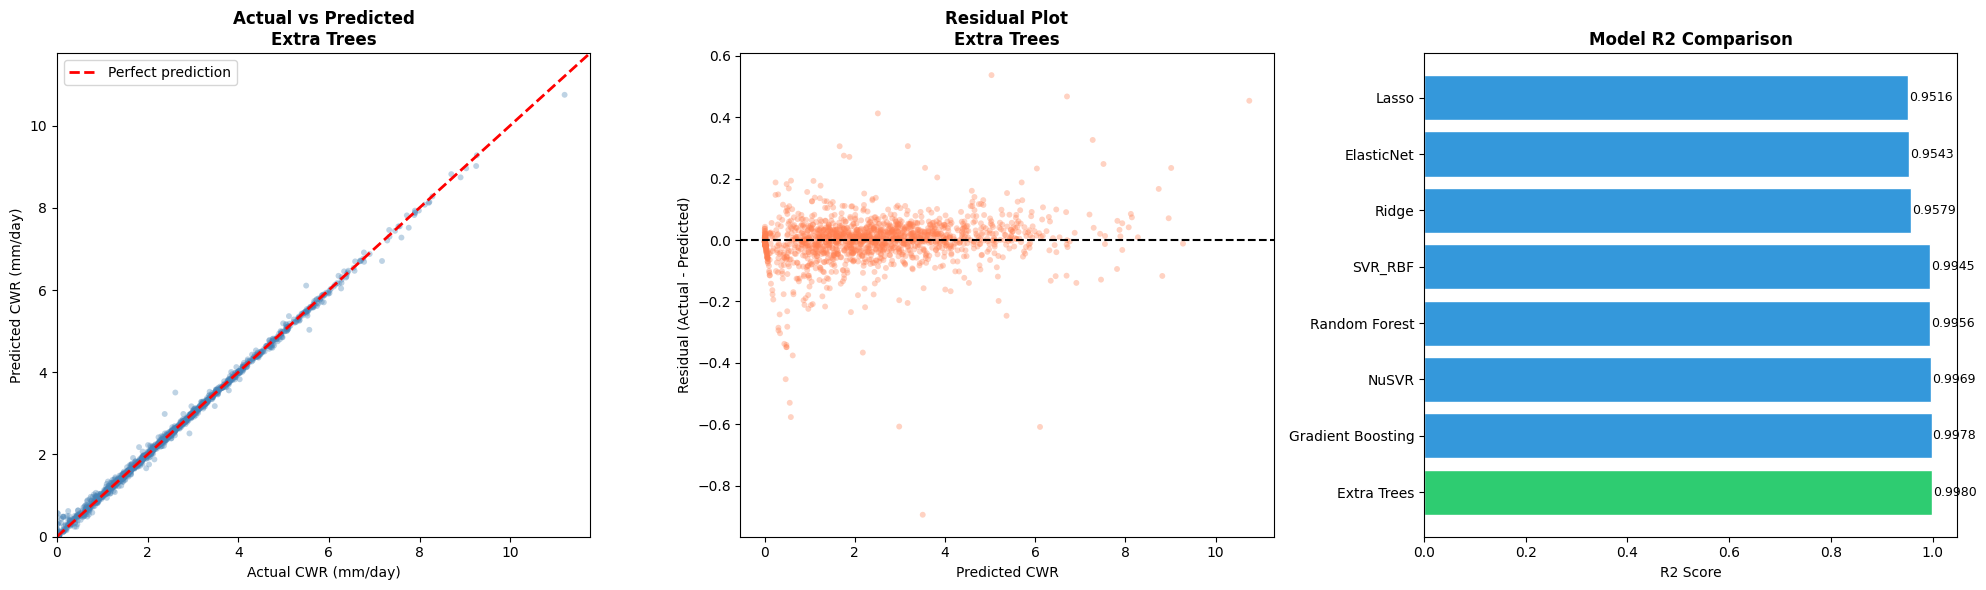

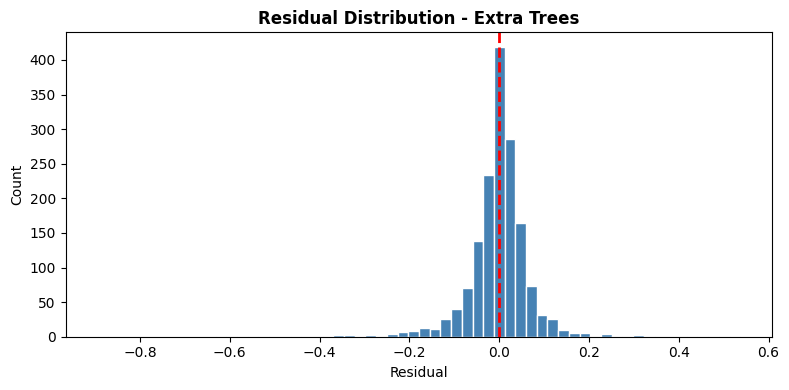

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(y_te_c, best_cwr_preds, alpha=0.35, s=18,
                color='steelblue', edgecolors='none')
lim = [0, max(y_te_c.max(), best_cwr_preds.max())*1.05]
axes[0].plot(lim, lim, 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual CWR (mm/day)')
axes[0].set_ylabel('Predicted CWR (mm/day)')
axes[0].set_title(f'Actual vs Predicted\n{best_cwr_name}', fontweight='bold')
axes[0].legend(); axes[0].set_xlim(lim); axes[0].set_ylim(lim)

residuals = y_te_c.values - best_cwr_preds
axes[1].scatter(best_cwr_preds, residuals, alpha=0.35, s=18,
                color='coral', edgecolors='none')
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Predicted CWR')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title(f'Residual Plot\n{best_cwr_name}', fontweight='bold')

colors = ['#2ecc71' if n==best_cwr_name else '#3498db' for n in cwr_df['Model']]
bars = axes[2].barh(cwr_df['Model'], cwr_df['R2'], color=colors, edgecolor='white')
axes[2].set_xlabel('R2 Score')
axes[2].set_title('Model R2 Comparison', fontweight='bold')
for bar, val in zip(bars, cwr_df['R2']):
    axes[2].text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
plt.hist(residuals, bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title(f'Residual Distribution - {best_cwr_name}', fontweight='bold')
plt.xlabel('Residual'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

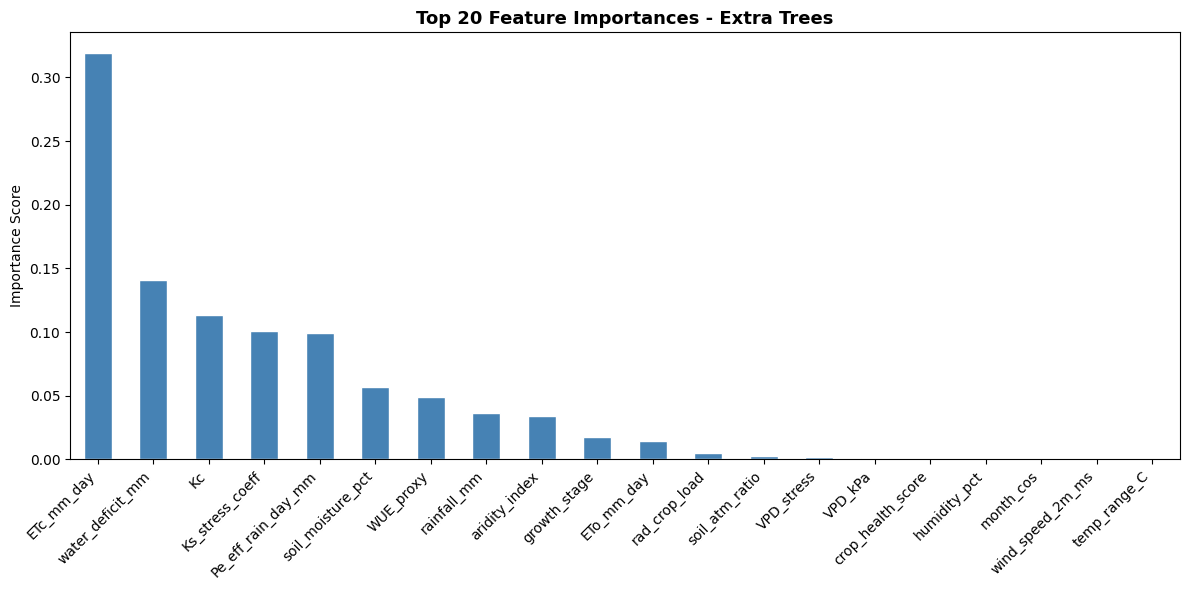

ETc_mm_day            0.319490
water_deficit_mm      0.140573
Kc                    0.113233
Ks_stress_coeff       0.101089
Pe_eff_rain_day_mm    0.099543
soil_moisture_pct     0.057094
WUE_proxy             0.049198
rainfall_mm           0.036207
aridity_index         0.034445
growth_stage          0.017516
ETo_mm_day            0.014706
rad_crop_load         0.004776
soil_atm_ratio        0.002480
VPD_stress            0.001552
VPD_kPa               0.001498
dtype: float64


In [ ]:
if hasattr(best_cwr_model, 'feature_importances_'):
    importances = pd.Series(best_cwr_model.feature_importances_,
                            index=FEATURES).sort_values(ascending=False)
else:
    perm = permutation_importance(best_cwr_model, X_te_cs, y_te_c,
                                  n_repeats=10, random_state=42, n_jobs=-1)
    importances = pd.Series(perm.importances_mean,
                            index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances.head(20).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title(f'Top 20 Feature Importances - {best_cwr_name}',
          fontweight='bold', fontsize=13)
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()
print(importances.head(15))

In [ ]:
y_fert = df['soil_fertility_score']
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X, y_fert, test_size=0.2, random_state=42)

scaler_fert = StandardScaler()
X_tr_fs     = scaler_fert.fit_transform(X_tr_f)
X_te_fs     = scaler_fert.transform(X_te_f)

fert_models = {
    'Random Forest':     RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                         max_depth=5, random_state=42),
    'Extra Trees':       ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet':        ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    'SVR_RBF':           SVR(kernel='rbf', C=10, epsilon=0.5, gamma='scale'),
}

fert_results, fert_preds = [], {}
print("Training Fertility Regression Models...")
for name, model in fert_models.items():
    model.fit(X_tr_fs, y_tr_f)
    res, yp = evaluate_regression(name, model, X_tr_fs, y_tr_f,
                                  X_te_fs, y_te_f, len(FEATURES))
    fert_results.append(res); fert_preds[name] = yp
    print(f"  {name:22s} | R2={res['R2']:.4f} | RMSE={res['RMSE']:.4f}"
          f" | CV={res['CV_R2_mean']:.4f}+-{res['CV_R2_std']:.4f}")

fert_df = pd.DataFrame(fert_results).sort_values('Adj_R2', ascending=False).reset_index(drop=True)
display(fert_df)
best_fert_name  = fert_df.iloc[0]['Model']
best_fert_model = fert_models[best_fert_name]
print(f"\nBest Fertility Model: {best_fert_name}")


Training Fertility Regression Models...
  Random Forest          | R2=0.9243 | RMSE=2.8028 | CV=0.9170+-0.0029
  Gradient Boosting      | R2=0.9332 | RMSE=2.6337 | CV=0.9291+-0.0036
  Extra Trees            | R2=0.9271 | RMSE=2.7510 | CV=0.9202+-0.0036
  Ridge                  | R2=0.9183 | RMSE=2.9123 | CV=0.9165+-0.0026
  Lasso                  | R2=0.9185 | RMSE=2.9080 | CV=0.9168+-0.0028
  ElasticNet             | R2=0.9186 | RMSE=2.9068 | CV=0.9165+-0.0027
  SVR_RBF                | R2=0.9159 | RMSE=2.9547 | CV=0.9146+-0.0027


,Model,MSE,RMSE,MAE,R2,Adj_R2,MAPE_pct,CV_R2_mean,CV_R2_std
0,Gradient Boosting,6.9361,2.6337,2.1170,0.9332,0.9314,3.33,0.9291,0.0036
1,Extra Trees,7.5679,2.7510,2.1961,0.9271,0.9252,3.50,0.9202,0.0036
2,Random Forest,7.8556,2.8028,2.2448,0.9243,0.9223,3.57,0.9170,0.0029
3,Lasso,8.4563,2.9080,2.3152,0.9185,0.9164,3.63,0.9168,0.0028
4,ElasticNet,8.4495,2.9068,2.3098,0.9186,0.9164,3.63,0.9165,0.0027
5,Ridge,8.4812,2.9123,2.3161,0.9183,0.9161,3.63,0.9165,0.0026
6,SVR_RBF,8.7303,2.9547,2.3464,0.9159,0.9137,3.70,0.9146,0.0027



Best Fertility Model: Gradient Boosting


In [ ]:
le      = LabelEncoder()
y_class = le.fit_transform(df['fertility_class'])
classes = le.classes_
print(f"Classes: {classes}")
print(f"Distribution: {dict(zip(*np.unique(y_class, return_counts=True)))}")

X_tr_cl, X_te_cl, y_tr_cl, y_te_cl = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class)

scaler_cl  = StandardScaler()
X_tr_cls   = scaler_cl.fit_transform(X_tr_cl)
X_te_cls   = scaler_cl.transform(X_te_cl)

clf_models = {
    'Random Forest':      RandomForestClassifier(n_estimators=300,
                          class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingClassifier(n_estimators=300,
                          learning_rate=0.05, max_depth=5, random_state=42),
    'Logistic Regression':LogisticRegression(max_iter=1000,
                          class_weight='balanced', multi_class='multinomial'),
    'SVC_RBF':            SVC(kernel='rbf', C=10, gamma='scale',
                          class_weight='balanced', probability=True),
}

clf_results, clf_preds, clf_reports, clf_cms = [], {}, {}, {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Training Classification Models...")
for name, model in clf_models.items():
    model.fit(X_tr_cls, y_tr_cl)
    res, yp, rpt, cm = evaluate_classification(name, model, X_te_cls, y_te_cl, classes)
    cv_acc = cross_val_score(model, X_tr_cls, y_tr_cl, cv=skf,
                             scoring='accuracy', n_jobs=-1)
    res['CV_Acc_mean'] = round(cv_acc.mean(), 4)
    res['CV_Acc_std']  = round(cv_acc.std(),  4)
    clf_results.append(res); clf_preds[name]=yp
    clf_reports[name]=rpt; clf_cms[name]=cm
    print(f"  {name:22s} | Acc={res['Accuracy']:.4f}"
          f" | F1={res['F1_weighted']:.4f}"
          f" | CV={res['CV_Acc_mean']:.4f}+-{res['CV_Acc_std']:.4f}")

clf_df = pd.DataFrame(clf_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
display(clf_df)
best_clf_name  = clf_df.iloc[0]['Model']
best_clf_model = clf_models[best_clf_name]
print(f"\nBest Classifier: {best_clf_name}")
print(f"\nClassification Report:\n{clf_reports[best_clf_name]}")


Classes: ['High' 'Low' 'Medium']
Distribution: {np.int64(0): np.int64(1452), np.int64(1): np.int64(613), np.int64(2): np.int64(5935)}
Training Classification Models...
  Random Forest          | Acc=0.8806 | F1=0.8696 | CV=0.8744+-0.0047
  Gradient Boosting      | Acc=0.9012 | F1=0.8987 | CV=0.8989+-0.0066
  Logistic Regression    | Acc=0.8506 | F1=0.8576 | CV=0.8559+-0.0075
  SVC_RBF                | Acc=0.8775 | F1=0.8793 | CV=0.8794+-0.0062


,Model,Accuracy,F1_weighted,CV_Acc_mean,CV_Acc_std
0,Gradient Boosting,0.9012,0.8987,0.8989,0.0066
1,Random Forest,0.8806,0.8696,0.8744,0.0047
2,SVC_RBF,0.8775,0.8793,0.8794,0.0062
3,Logistic Regression,0.8506,0.8576,0.8559,0.0075



Best Classifier: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.75      0.80       290
         Low       0.85      0.71      0.77       123
      Medium       0.91      0.96      0.94      1187

    accuracy                           0.90      1600
   macro avg       0.88      0.81      0.84      1600
weighted avg       0.90      0.90      0.90      1600



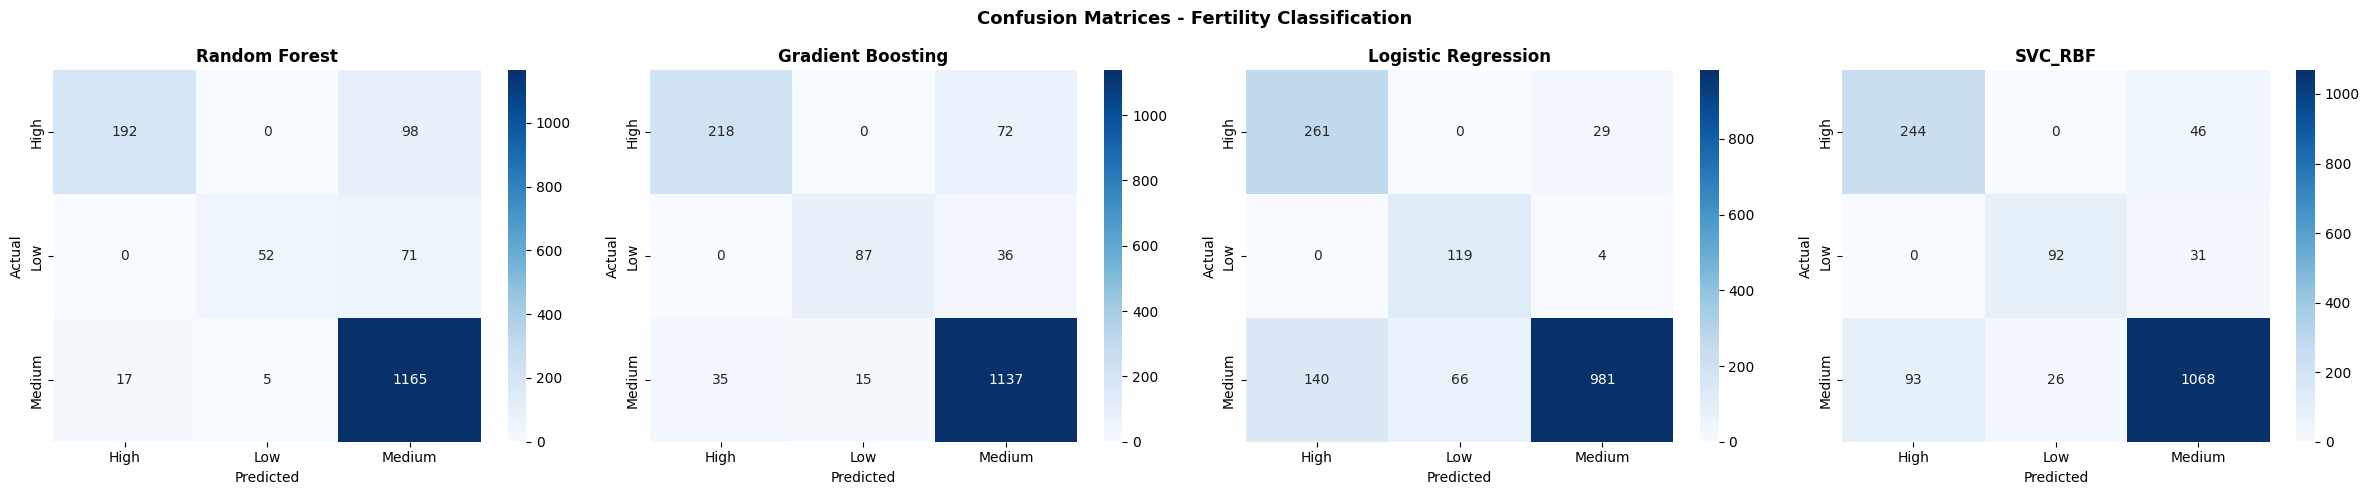

In [ ]:

fig, axes = plt.subplots(1, len(clf_models), figsize=(6*len(clf_models), 5))
if len(clf_models) == 1: axes = [axes]
for ax, (name, cm) in zip(axes, clf_cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices - Fertility Classification',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
y_irr = df['irrigation_needed']
print(f"Irrigation YES: {y_irr.mean()*100:.1f}% | NO: {(1-y_irr.mean())*100:.1f}%")

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X, y_irr, test_size=0.2, random_state=42, stratify=y_irr)

scaler_irr = StandardScaler()
X_tr_is    = scaler_irr.fit_transform(X_tr_i)
X_te_is    = scaler_irr.transform(X_te_i)

irr_models = {
    'Random Forest':      RandomForestClassifier(n_estimators=300,
                          class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingClassifier(n_estimators=300,
                          learning_rate=0.05, random_state=42),
    'Logistic Regression':LogisticRegression(max_iter=1000, class_weight='balanced'),
    'SVC_RBF':            SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced'),
}

irr_results = []
print("Training Irrigation Binary Classification...")
for name, model in irr_models.items():
    model.fit(X_tr_is, y_tr_i)
    yp      = model.predict(X_te_is)
    acc     = accuracy_score(y_te_i, yp)
    f1      = f1_score(y_te_i, yp, average='weighted')
    cv_acc  = cross_val_score(model, X_tr_is, y_tr_i, cv=5,
                               scoring='accuracy', n_jobs=-1)
    irr_results.append({'Model':name,'Accuracy':round(acc,4),
                        'F1':round(f1,4),'CV_Acc':round(cv_acc.mean(),4),
                        'CV_Std':round(cv_acc.std(),4)})
    print(f"  {name:22s} | Acc={acc:.4f} | F1={f1:.4f}"
          f" | CV={cv_acc.mean():.4f}+-{cv_acc.std():.4f}")

irr_df = pd.DataFrame(irr_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
display(irr_df)
best_irr_name  = irr_df.iloc[0]['Model']
best_irr_model = irr_models[best_irr_name]


Irrigation YES: 85.4% | NO: 14.6%
Training Irrigation Binary Classification...
  Random Forest          | Acc=0.9738 | F1=0.9732 | CV=0.9725+-0.0027
  Gradient Boosting      | Acc=0.9856 | F1=0.9855 | CV=0.9841+-0.0023
  Logistic Regression    | Acc=0.9650 | F1=0.9664 | CV=0.9700+-0.0029
  SVC_RBF                | Acc=0.9812 | F1=0.9814 | CV=0.9853+-0.0025


,Model,Accuracy,F1,CV_Acc,CV_Std
0,Gradient Boosting,0.9856,0.9855,0.9841,0.0023
1,SVC_RBF,0.9812,0.9814,0.9853,0.0025
2,Random Forest,0.9738,0.9732,0.9725,0.0027
3,Logistic Regression,0.9650,0.9664,0.9700,0.0029


In [ ]:
LAT_RAD_P = math.radians(18.52); ELEV_P = 560.0

doy_n=200; month_n=7; hour_n=10; gs_n=3
T_mean_n=27.0; T_max_n=32.0; T_min_n=23.0
hum_n=82.0; wind_n_10m=4.2; rain_n=85.0; sun_n=5.5
sm_n=62.0; ph_n=6.8; N_n=160.0; P_n=35.0; K_n=190.0; health_n=72.0

# FAO-56 computed on Pi
dr_n  = 1+0.033*math.cos(2*math.pi*doy_n/365)
del_n = 0.409*math.sin(2*math.pi*doy_n/365-1.39)
ws_n  = math.acos(max(-1,min(1,-math.tan(LAT_RAD_P)*math.tan(del_n))))
Ra_n  = (24*60/math.pi)*0.0820*dr_n*(ws_n*math.sin(LAT_RAD_P)*math.sin(del_n)+
         math.cos(LAT_RAD_P)*math.cos(del_n)*math.sin(ws_n))
Nd_n  = (24/math.pi)*ws_n
Rs_n  = (0.25+0.50*(sun_n/Nd_n))*Ra_n
Rso_n = (0.75+2e-5*ELEV_P)*Ra_n
Rns_n = 0.77*Rs_n
ea_n  = (hum_n/100)*0.6108*math.exp(17.27*T_mean_n/(T_mean_n+237.3))
sigma = 4.903e-9
Rnl_n = sigma*((T_max_n+273.16)**4+(T_min_n+273.16)**4)/2*(
         0.34-0.14*math.sqrt(ea_n))*max(0.05,min(1.0,1.35*(Rs_n/max(Rso_n,0.001))-0.35))
Rn_n  = max(Rns_n-Rnl_n,0)
es_max_n=0.6108*math.exp(17.27*T_max_n/(T_max_n+237.3))
es_min_n=0.6108*math.exp(17.27*T_min_n/(T_min_n+237.3))
es_n  = (es_max_n+es_min_n)/2
VPD_n = es_n-ea_n
Delta_n=4098*es_n/(T_mean_n+237.3)**2
P_atm_n=101.3*((293-0.0065*ELEV_P)/293)**5.26
gam_n = 0.000665*P_atm_n
w2_n  = wind_n_10m*(4.87/math.log(67.8*10-5.42))
ETo_n = max((0.408*Delta_n*(Rn_n-0)+gam_n*(900/(T_mean_n+273))*w2_n*VPD_n)/
            (Delta_n+gam_n*(1+0.34*w2_n)),0)
Kc_n  = {1:0.40,2:0.85,3:1.15,4:0.70}[gs_n]
ETc_n = ETo_n*Kc_n
Pe_n  = min(rain_n*(125-0.6*rain_n)/125 if rain_n<75 else 125+0.1*rain_n,rain_n)/30
Ks_n  = min(1.0,max(0,(sm_n-20)/60)/0.5)

new_vals = {
    'doy_sin':math.sin(2*math.pi*doy_n/365),'doy_cos':math.cos(2*math.pi*doy_n/365),
    'month_sin':math.sin(2*math.pi*month_n/12),'month_cos':math.cos(2*math.pi*month_n/12),
    'hour_sin':math.sin(2*math.pi*hour_n/24),'hour_cos':math.cos(2*math.pi*hour_n/24),
    'growth_stage':gs_n,'temperature_mean_C':T_mean_n,'temperature_max_C':T_max_n,
    'temperature_min_C':T_min_n,'humidity_pct':hum_n,'temp_range_C':T_max_n-T_min_n,
    'heat_stress':max(0,(T_max_n-35)*0.1),'wind_speed_2m_ms':w2_n,'rainfall_mm':rain_n,
    'sunshine_hours':sun_n,'soil_moisture_pct':sm_n,'soil_ph':ph_n,
    'nitrogen_mgkg':N_n,'phosphorus_mgkg':P_n,'potassium_mgkg':K_n,
    'NPK_composite':(N_n/280+P_n/56+K_n/336)/3*100,'crop_health_score':health_n,
    'Ra_MJ_m2_day':Ra_n,'Rs_MJ_m2_day':Rs_n,'Rn_MJ_m2_day':Rn_n,
    'es_kPa':es_n,'ea_kPa':ea_n,'VPD_kPa':VPD_n,'VPD_stress':max(0,VPD_n-1.0),
    'ETo_mm_day':ETo_n,'Kc':Kc_n,'ETc_mm_day':ETc_n,'Ks_stress_coeff':Ks_n,
    'Pe_eff_rain_day_mm':Pe_n,'aridity_index':rain_n/(ETo_n+1e-6),
    'water_deficit_mm':max(ETo_n-Pe_n,0),'pH_deviation':abs(ph_n-6.5),
    'soil_atm_ratio':sm_n/(ETo_n+1e-6),'rad_crop_load':Rs_n*Kc_n,
    'WUE_proxy':health_n/(ETc_n+1e-6),
}
new_df = pd.DataFrame([new_vals])[FEATURES]

print("=" * 60)
print("NEW SENSOR READING — PREDICTIONS")
print("=" * 60)
print(f"Date: Day {doy_n} (Month {month_n}) | Growth: {'Flowering'}")
print(f"Temp: {T_mean_n}C | Humidity: {hum_n}% | Rain: {rain_n}mm")
print(f"Soil: moisture={sm_n}% | pH={ph_n}")
print(f"NPK: N={N_n} P={P_n} K={K_n} mg/kg")
print(f"FAO-56: ETo={ETo_n:.3f} mm/day | ETc={ETc_n:.3f} mm/day")

print("\nCWR Predictions (all models):")
for name, model in cwr_models.items():
    pred = max(0, model.predict(scaler_cwr.transform(new_df))[0])
    print(f"  {name:22s}: {pred:.4f} mm/day")

print("\nFertility Score Predictions:")
for name, model in fert_models.items():
    pred = model.predict(scaler_fert.transform(new_df))[0]
    print(f"  {name:22s}: {pred:.2f}/100")

fc_pred = best_clf_model.predict(scaler_cl.transform(new_df))[0]
print(f"\nFertility Class ({best_clf_name}): {le.inverse_transform([fc_pred])[0]}")

ir_pred = best_irr_model.predict(scaler_irr.transform(new_df))[0]
print(f"Irrigation Decision ({best_irr_name}): "
      f"{'YES - Irrigate today!' if ir_pred==1 else 'NO - Sufficient water'}")



NEW SENSOR READING — PREDICTIONS
Date: Day 200 (Month 7) | Growth: Flowering
Temp: 27.0C | Humidity: 82.0% | Rain: 85.0mm
Soil: moisture=62.0% | pH=6.8
NPK: N=160.0 P=35.0 K=190.0 mg/kg
FAO-56: ETo=4.524 mm/day | ETc=5.203 mm/day

CWR Predictions (all models):
  Random Forest         : 2.2863 mm/day
  Gradient Boosting     : 2.3998 mm/day
  Extra Trees           : 2.2332 mm/day
  Ridge                 : 2.5446 mm/day
  Lasso                 : 2.6242 mm/day
  ElasticNet            : 2.6458 mm/day
  SVR_RBF               : 2.2172 mm/day
  NuSVR                 : 2.2343 mm/day

Fertility Score Predictions:
  Random Forest         : 68.88/100
  Gradient Boosting     : 70.39/100
  Extra Trees           : 69.67/100
  Ridge                 : 69.11/100
  Lasso                 : 69.20/100
  ElasticNet            : 69.36/100
  SVR_RBF               : 70.14/100

Fertility Class (Gradient Boosting): Medium
Irrigation Decision (Gradient Boosting): YES - Irrigate today!
